# Statistical Arbitrage in the U.S. Equities Market  
https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1153505  

This paper develops a statistical arbitrage strategy based on **mean reversion** across a large universe of equities. The key idea of statistical arbitrage is:

- Identify assets that share common movements (driven by underlying factors)
- Detect temporary mispricings
- Trade on the expectation that prices will revert back to equilibrium

---

## Factor Model Representation

Stock returns are decomposed as:

$$
R_i = \sum_{j=1}^{m} \beta_{ij} F_j + \widetilde{R}_i
$$

where:
- $R_i$ = return of stock $i$  
- $F_j$ = common factors  
- $\beta_{ij}$ = exposure of stock $i$ to factor $j$  
- $\widetilde{R}_i$ = idiosyncratic residual  

The goal is to isolate $\widetilde{R}_i$ and trade its mean reversion.

---

## PCA for Factor Extraction

Instead of choosing factors manually, the paper uses **Principal Component Analysis (PCA)**.

Steps:
1. Standardize returns:
$$
Y_{ik} = \frac{R_{ik} - \bar{R}_i}{\sigma_i}
$$

2. Construct the correlation matrix:
$$
\rho_{ij} = \frac{1}{M-1} \sum_{k=1}^{M} Y_{ik} Y_{jk}
$$

3. Perform eigen-decomposition:
$$
\rho v^{(j)} = \lambda_j v^{(j)}
$$

- $\lambda_j$ = eigenvalues (importance of factor)
- $v^{(j)}$ = eigenvectors (factor directions)

We select:
- The top 15 eigenvalues **or**
- Enough components to explain ~55% of total variance

These define the **latent factors** driving the market.

---

## Eigenportfolio Construction

Each eigenvector defines a portfolio:

$$
Q_i^{(j)} = \frac{v_i^{(j)}}{\sigma_i}
$$

Factor returns are:

$$
F_j = \sum_{i=1}^{N} \frac{v_i^{(j)}}{\sigma_i} R_i
$$

These eigenportfolios are approximately uncorrelated.

---

## Residual Modeling (Mean Reversion)

After removing factor exposure, residuals are modeled as an **Ornstein-Uhlenbeck (OU) process**:

$$
dX_i(t) = \kappa_i (m_i - X_i(t)) dt + \sigma_i dW_i(t)
$$

where:
- $\kappa_i$ = speed of mean reversion  
- $m_i$ = long-term mean  
- $\sigma_i$ = volatility  

---

## OU Properties

Mean and variance:

$$
\mathbb{E}[X_i] = m_i
$$

$$
\text{Var}(X_i) = \frac{\sigma_i^2}{2\kappa_i}
$$

Mean-reversion timescale:

$$
\tau_i = \frac{1}{\kappa_i}
$$

Only stocks with **fast mean reversion** (small $\tau_i$) are selected.

---

## S-Score (Trading Signal)

The normalized mispricing signal:

$$
s_i = \frac{X_i(t) - m_i}{\sigma_{\text{eq},i}}
$$

where:

$$
\sigma_{\text{eq},i} = \frac{\sigma_i}{\sqrt{2\kappa_i}}
$$

Interpretation:
- $s_i > 0$ → stock is overpriced  
- $s_i < 0$ → stock is underpriced  

---

## Trading Rules

- **Open long** if:
$$
s_i < -1.25
$$

- **Open short** if:
$$
s_i > 1.25
$$

- **Close positions** when:
$$
s_i \to 0
$$

---

## Full Strategy Pipeline

1. Collect returns for ~100 stocks  
2. Standardize returns  
3. Build correlation matrix  
4. Apply PCA  
5. Select top components  
6. Construct eigenportfolios  
7. Remove factor exposures  
8. Compute residuals  
9. Fit OU process  
10. Filter for fast mean-reverting stocks  
11. Compute $s$-scores  
12. Trade mean reversion  

---

## Core Insight

The strategy is:

$$
\text{Returns} = \text{Factors} + \text{Residual}
$$

$$
\text{Trade} = \text{Mean Reversion of Residual}
$$

This ensures:
- Market neutrality  
- Factor neutrality  
- Pure relative-value trading  

The edge comes from exploiting **temporary deviations from equilibrium** in the residual component.

In [2]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


universe = [
    # Semiconductors / equipment / EDA
    "NVDA","AMD","AVGO","MU","AMAT","LRCX","KLAC","ADI","TXN","INTC",
    "QCOM","MRVL","NXPI","MCHP","ON","MPWR","TER","ENTG","SWKS","LSCC",
    "RMBS","QRVO","COHR","SYNA","IPGP","ALGM","CRUS","DIOD","FORM","POWI",
    "AEIS","SITM","MKSI","AMKR","ASML","TSM","SNPS","CDNS","STM",

    # Software / cloud / data / dev tools
    "MSFT","ORCL","CRM","NOW","ADBE","INTU","ADSK","DDOG","MDB","SNOW",
    "HUBS","SHOP","TEAM","GTLB","ESTC","PATH","CFLT","DOCN","AI","WK",
    "BOX","DBX","NTAP","WDAY","FICO","ROP","U","ZI","TWLO","PAYC",
    "VEEV","ANSS","MANH","BILL","PCOR","DT","APP","PLTR",

    # Cybersecurity / networking / infrastructure software
    "CRWD","PANW","FTNT","NET","ZS","OKTA","CHKP","FFIV","AKAM","CSCO",
    "ANET","GEN","QLYS","VRNS","TENB","RDWR","ATEN","NTCT","CVLT","RPD",
    "LDOS","BAH","IBM","JNPR","CIEN"
]

In [7]:
# Load Prices
print(f"Number of tickers in universe: {len(universe)}")

start_date = "2018-01-01"
end_date = None  # use latest available date

raw = yf.download(
    tickers=universe,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

# with auto_adjust=True, use Close
prices = raw["Close"].copy()

# sort dates and columns
prices = prices.sort_index()
prices = prices.reindex(sorted(prices.columns), axis=1)

# basic missing-data report
missing_pct = prices.isna().mean().sort_values(ascending=False)
print("\nTop missing percentages:")
print((100 * missing_pct.head(15)).round(2))

# drop columns that are completely missing
prices = prices.dropna(axis=1, how="all")

print("\nFinal price panel shape:", prices.shape)
print("Start:", prices.index.min())
print("End:", prices.index.max())

min_obs = 252

mask = prices.notna().sum() >= min_obs
print("Tickers kept:", mask.sum())
print("Tickers removed:", (~mask).sum())

prices = prices.loc[:, mask]

print("NEW shape:", prices.shape)


Number of tickers in universe: 102


$ZI: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found

3 Failed downloads:
['ZI', 'JNPR', 'ANSS']: possibly delisted; no timezone found



Top missing percentages:
Ticker
ANSS    100.00
JNPR    100.00
ZI      100.00
GTLB     46.04
CFLT     42.66
PCOR     41.11
PATH     40.10
APP      39.90
DOCN     39.18
AI       35.75
ALGM     34.40
PLTR     33.38
U        33.00
SNOW     32.90
BILL     23.67
dtype: float64

Final price panel shape: (2070, 99)
Start: 2018-01-02 00:00:00
End: 2026-03-27 00:00:00
Tickers kept: 99
Tickers removed: 0
NEW shape: (2070, 99)


In [10]:
# Compute Daily Returns

returns = prices.pct_change(fill_method=None)

print("Returns shape:", returns.shape)
print("Start of returns index:", returns.index.min())
print("End of returns index:", returns.index.max())

# inspect missingness
ret_missing_pct = (100 * returns.isna().mean()).sort_values(ascending=False)
print("\nTop return missing percentages:")
print(ret_missing_pct.head(15).round(2))

print(returns.head())
print(returns.tail())

Returns shape: (2070, 99)
Start of returns index: 2018-01-02 00:00:00
End of returns index: 2026-03-27 00:00:00

Top return missing percentages:
Ticker
GTLB    46.09
CFLT    42.71
PCOR    41.16
PATH    40.14
APP     39.95
DOCN    39.23
AI      35.80
ALGM    34.44
PLTR    33.43
U       33.04
SNOW    32.95
BILL    23.72
SITM    23.00
DDOG    20.87
NET     20.68
dtype: float64
Ticker          ADBE       ADI      ADSK      AEIS  AI      AKAM  ALGM  \
Date                                                                     
2018-01-02       NaN       NaN       NaN       NaN NaN       NaN   NaN   
2018-01-03  0.018796  0.012406  0.021098 -0.007060 NaN  0.005796   NaN   
2018-01-04  0.012042 -0.001095  0.024593 -0.013929 NaN -0.005156   NaN   
2018-01-05  0.011571  0.004052 -0.010975  0.057240 NaN  0.003506   NaN   
2018-01-08 -0.001619  0.001746  0.005233 -0.002923 NaN  0.000759   NaN   

Ticker          AMAT       AMD      AMKR  ...       TER       TSM      TWLO  \
Date                     

In [12]:
# Build Rolling 1 Year windows

window = 252

# valid time index where we can run PCA
valid_dates = returns.index[window:]

print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2070
Number of valid PCA dates: 1818
First PCA date: 2019-01-03 00:00:00


In [14]:
# Standardize Returns Y(i,t) = (R(i,t) - R(Mean over Window) / Volatility over window)

# pick first PCA date
t = valid_dates[0]

# get rolling window
window_data = returns.loc[:t].tail(252)

# drop columns with ANY NaNs in this window
window_data = window_data.dropna(axis=1)

print("Window shape after NaN drop:", window_data.shape)

# compute mean and std (per stock)
mu = window_data.mean()
sigma = window_data.std()

# standardize
Y = (window_data - mu) / sigma

# checks
print("\nMean (should be ~0):")
print(Y.mean().abs().mean())

print("\nStd (should be ~1):")
print((Y.std() - 1).abs().mean())

print(Y.head())

Window shape after NaN drop: (252, 78)

Mean (should be ~0):
1.481822397794107e-17

Std (should be ~1):
4.2700885562506023e-17
Ticker          ADBE       ADI      ADSK      AEIS      AKAM      AMAT  \
Date                                                                     
2018-01-03  0.792125  0.715493  0.772409 -0.214502  0.297341  0.768237   
2018-01-04  0.491147 -0.050256  0.905727 -0.493841 -0.236653  0.293828   
2018-01-05  0.470166  0.241676 -0.450886  2.400071  0.185684  0.292538   
2018-01-08 -0.117584  0.110841  0.167305 -0.046290  0.051769  1.023806   
2018-01-09  0.354317 -0.105533  0.203921 -1.425900  1.206239 -0.684258   

Ticker           AMD      AMKR      ANET      ASML  ...      SYNA      TEAM  \
Date                                                ...                       
2018-01-03  1.236184 -0.048495  0.651143  0.356207  ...  0.358121  2.351217   
2018-01-04  1.172031  2.362492 -0.401050  0.432830  ...  0.227983  0.725842   
2018-01-05 -0.559549 -0.436552  0.5775

In [15]:
# Build The Correlation matrix 

corr = Y.corr()

print("Correlation matrix shape:", corr.shape)

# sanity checks
print("\nIs symmetric:", np.allclose(corr, corr.T))
print("Diagonal (should be 1):", np.mean(np.diag(corr)))

# eigenvalue sanity check (no negatives ideally)
eigvals = np.linalg.eigvalsh(corr)
print("\nMin eigenvalue:", eigvals.min())

Correlation matrix shape: (78, 78)

Is symmetric: True
Diagonal (should be 1): 1.0

Min eigenvalue: 0.043242870325256394


In [16]:
# PCA Eigendecomposition

# eigen decomposition (symmetric matrix → use eigh)
eigvals, eigvecs = np.linalg.eigh(corr)

# sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("Top 10 eigenvalues:")
print(eigvals[:10])

# explained variance ratio
explained = eigvals / eigvals.sum()

print("\nTop 10 explained variance ratios:")
print(explained[:10])

print("\nTotal explained by top 15:")
print(explained[:15].sum())

Top 10 eigenvalues:
[37.58512096  5.23025744  2.04589354  1.46493188  1.31528522  1.23093213
  1.2300009   1.10750209  1.05113935  1.02253236]

Top 10 explained variance ratios:
[0.48186053 0.06705458 0.0262294  0.01878118 0.01686263 0.01578118
 0.01576924 0.01419874 0.01347615 0.01310939]

Total explained by top 15:
0.7389999939164387


In [17]:
k = 15
V = eigvecs[:, :k]   # eigenvectors
Lambda = eigvals[:k] # eigenvalues

In [21]:
# Convert PCA into tradable factor returns, eigenportfoilios

# align sigma with columns
sigma_vec = sigma.loc[window_data.columns]

# compute Q (weights)
Q = V / sigma_vec.values[:, None]

print("Q shape:", Q.shape)  # should be (78, 15)

# compute factor returns
F = window_data.values @ Q   # (252 × 78) @ (78 × 15) = (252 × 15)

F = pd.DataFrame(F, index=window_data.index)

print("Factor return shape:", F.shape)

print(F.head())

print("Factor correlation (should be ~0 off-diagonal):")
print(F.corr().round(2))

Q shape: (78, 15)
Factor return shape: (252, 15)
                  0         1         2         3         4         5   \
Date                                                                     
2018-01-03  5.033826 -0.033703 -0.347799  1.321977 -1.001278  0.497828   
2018-01-04  3.591556  1.005246 -0.434010 -0.101554 -0.313438  0.104832   
2018-01-05  2.214136 -0.866645 -0.784647  0.948963 -0.090309  0.184956   
2018-01-08  3.414494  0.615445 -0.526751 -0.692682 -0.129565 -0.148395   
2018-01-09 -2.515402  1.475396 -0.892760  0.599909  0.924427  1.001514   

                  6         7         8         9         10        11  \
Date                                                                     
2018-01-03 -1.000528 -1.475495 -0.212772 -0.279003  1.476583 -0.397290   
2018-01-04  0.585929 -0.729814  0.843342 -0.377317  0.417575  0.397957   
2018-01-05  0.315923  0.693323  0.025448 -0.235743 -0.096700 -0.394788   
2018-01-08  1.042204 -1.689934  0.004479 -1.431035  0.789129 -

In [25]:
# Regress on last 60 returns

import statsmodels.api as sm

# pick same window end t
t = valid_dates[0]

# get last 60 days
reg_window = returns.loc[:t].tail(60)

# keep only stocks used in PCA (same columns)
reg_window = reg_window[window_data.columns]

# align factor returns
F_reg = F.loc[reg_window.index]

# pick one stock
stock = reg_window.columns[0]

y = reg_window[stock]
X = F_reg.copy()

# add intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

residuals = model.resid

print("Residual shape:", residuals.shape)
display(residuals.head())

print(y.index.equals(X.index))

                            OLS Regression Results                            
Dep. Variable:                   ADBE   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     29.85
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           3.75e-18
Time:                        17:03:23   Log-Likelihood:                 188.60
No. Observations:                  60   AIC:                            -345.2
Df Residuals:                      44   BIC:                            -311.7
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.002     -0.126      0.9

Date
2018-10-08    0.004231
2018-10-09    0.005140
2018-10-10    0.002533
2018-10-11    0.022184
2018-10-12   -0.006931
dtype: float64

True


In [27]:
# Build Residual Process Xk

# Step 9: cumulative residual process

X = residuals.cumsum()

print("X shape:", X.shape)

display(X.head())

print("Last value (should be ~0):", X.iloc[-1])

X shape: (60,)


Date
2018-10-08    0.004231
2018-10-09    0.009371
2018-10-10    0.011904
2018-10-11    0.034088
2018-10-12    0.027158
dtype: float64

Last value (should be ~0): 6.357761539454998e-16


In [30]:
# Fit the AR(1) OU  (Markets move discretly not continouly)

X_lag = X.shift(1).dropna()
X_now = X.loc[X_lag.index]

# regression: X_now = a + b * X_lag
X_reg = sm.add_constant(X_lag)

model_ar = sm.OLS(X_now, X_reg).fit()

print(model_ar.summary())
a = model_ar.params.iloc[0]
b = model_ar.params.iloc[1]

print("a:", a)
print("b:", b)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     95.30
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           9.01e-14
Time:                        17:06:38   Log-Likelihood:                 188.13
No. Observations:                  59   AIC:                            -372.3
Df Residuals:                      57   BIC:                            -368.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0046      0.002      2.016      0.0

In [31]:
print(model_ar.params)

print("b in (0,1)?", 0 < b < 1)

const    0.004609
0        0.795505
dtype: float64
b in (0,1)? True


In [33]:
# convert into k, m , std(eq) convert regression to OU

# residuals from AR(1)
zeta = model_ar.resid

# compute OU parameters
kappa = -np.log(b) * 252
m = a / (1 - b)
sigma_eq = np.sqrt(zeta.var() / (1 - b**2))

print("kappa:", kappa)
print("m:", m)
print("sigma_eq:", sigma_eq)

tau = 1 / kappa
print("Mean reversion time (years):", tau)
print("Mean reversion time (days):", tau * 252)

kappa: 57.65213566665381
m: 0.02253691916585985
sigma_eq: 0.01660361507884974
Mean reversion time (years): 0.017345411205267863
Mean reversion time (days): 4.371043623727502


In [34]:
# Center m 

# placeholder (will change later when we loop all stocks)
m_centered = m

In [35]:
# Score trading signal s = ((Current Cumulative Resid)-equilbrium level)/ std (eq)

# current value (last point)
X_t = X.iloc[-1]

s = (X_t - m_centered) / sigma_eq

print("s-score:", s)

s-score: -1.357350134825007


In [36]:
# trading signal

if s < -1.25:
    signal = "LONG"
elif s > 1.25:
    signal = "SHORT"
else:
    signal = "NONE"

print("Signal:", signal)

Signal: LONG


In [37]:
# Scale all of this to all stocks


import statsmodels.api as sm
import numpy as np
import pandas as pd

t = valid_dates[0]

# 1) windows
window_data = returns.loc[:t].tail(252)
window_data = window_data.dropna(axis=1)

# standardize (recompute to be safe)
mu = window_data.mean()
sigma = window_data.std().replace(0, np.nan)
window_data = window_data.dropna(axis=1)
sigma = sigma.loc[window_data.columns]

Y = (window_data - mu) / sigma

# 2) correlation + PCA
corr = Y.corr()
eigvals, eigvecs = np.linalg.eigh(corr)
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]
V = eigvecs[:, :15]

# 3) eigenportfolio weights + factors
Q = V / sigma.values[:, None]
F = pd.DataFrame(window_data.values @ Q, index=window_data.index)

# 4) regression window (60 days)
reg_window = window_data.tail(60)
F_reg = F.loc[reg_window.index]

# 5) loop over stocks
results = []

for stock in reg_window.columns:
    y = reg_window[stock]
    X = sm.add_constant(F_reg)

    model = sm.OLS(y, X).fit()
    resid = model.resid

    # Step 9: cumulative
    X_series = resid.cumsum()

    # Step 10: AR(1)
    X_lag = X_series.shift(1).dropna()
    X_now = X_series.loc[X_lag.index]
    X_reg = sm.add_constant(X_lag)

    ar = sm.OLS(X_now, X_reg).fit()

    a = ar.params.iloc[0]
    b = ar.params.iloc[1]

    # filter valid OU
    if not (0 < b < 1):
        continue

    # Step 11: OU params
    zeta = ar.resid
    kappa = -np.log(b) * 252

    # filter speed
    if kappa <= 8.4:
        continue

    m = a / (1 - b)
    sigma_eq = np.sqrt(zeta.var() / (1 - b**2))

    # Step 13: s-score
    X_t = X_series.iloc[-1]
    s = (X_t - m) / sigma_eq

    results.append({
        "stock": stock,
        "s": s,
        "kappa": kappa
    })

signals_df = pd.DataFrame(results).set_index("stock")

print("Number of tradable stocks:", len(signals_df))
display(signals_df.sort_values("s").head())
display(signals_df.sort_values("s").tail())

Number of tradable stocks: 78


,s,kappa
stock,,
NOW,-2.200089,44.194045
GEN,-2.037323,45.250537
AMD,-2.001607,38.265738
NTCT,-1.844999,18.542811
SWKS,-1.589362,59.360381


,s,kappa
stock,,
ENTG,1.596200,26.480708
RDWR,1.735420,31.220668
BOX,1.958975,81.362123
WK,2.088962,15.770228
MANH,2.432664,70.005431


In [38]:
# add signals

def get_signal(s):
    if s < -1.25:
        return "LONG"
    elif s > 1.25:
        return "SHORT"
    else:
        return "NONE"

signals_df["signal"] = signals_df["s"].apply(get_signal)

display(signals_df[signals_df["signal"] != "NONE"])

,s,kappa,signal
stock,,,
ADBE,-1.357350,57.652136,LONG
AMD,-2.001607,38.265738,LONG
AMKR,1.506623,24.535803,SHORT
ATEN,1.351306,15.348061,SHORT
BAH,-1.564185,11.484222,LONG
BOX,1.958975,81.362123,SHORT
ENTG,1.596200,26.480708,SHORT
GEN,-2.037323,45.250537,LONG
LDOS,-1.362806,24.281120,LONG


In [42]:
# backtest

pnl_series = []

dates = valid_dates

for t in dates:

    # --- SAME PIPELINE AS BEFORE ---
    window_data = returns.loc[:t].tail(252).dropna(axis=1)

    mu = window_data.mean()
    sigma = window_data.std().replace(0, np.nan)
    window_data = window_data.dropna(axis=1)
    sigma = sigma.loc[window_data.columns]

    Y = (window_data - mu) / sigma

    corr = Y.corr()
    eigvals, eigvecs = np.linalg.eigh(corr)
    idx = np.argsort(eigvals)[::-1]
    V = eigvecs[:, idx][:, :15]

    Q = V / sigma.values[:, None]
    F = pd.DataFrame(window_data.values @ Q, index=window_data.index)

    reg_window = window_data.tail(60)
    F_reg = F.loc[reg_window.index]

    signals = {}

    for stock in reg_window.columns:

        y = reg_window[stock]
        X = sm.add_constant(F_reg)

        model = sm.OLS(y, X).fit()
        resid = model.resid
        X_series = resid.cumsum()

        X_lag = X_series.shift(1).dropna()
        X_now = X_series.loc[X_lag.index]
        X_reg = sm.add_constant(X_lag)

        ar = sm.OLS(X_now, X_reg).fit()
        a = ar.params.iloc[0]
        b = ar.params.iloc[1]

        if not (0 < b < 1):
            continue

        kappa = -np.log(b) * 252
        if kappa <= 8.4:
            continue

        zeta = ar.resid
        m = a / (1 - b)
        sigma_eq = np.sqrt(zeta.var() / (1 - b**2))

        X_t = X_series.iloc[-1]
        s = (X_t - m) / sigma_eq

        if s < -1.25:
            signals[stock] = 1
        elif s > 1.25:
            signals[stock] = -1

    # --- PnL ---
    if len(signals) == 0:
        pnl_series.append(0)
        continue

    idx = returns.index.get_loc(t)

    if idx + 1 >= len(returns.index):
        pnl_series.append(0)
        continue

    next_day = returns.index[idx + 1]

    pnl = 0
    for stock, pos in signals.items():
        pnl += pos * returns.loc[next_day, stock]

    pnl /= len(signals)

    pnl_series.append(pnl)

pnl_series = pd.Series(pnl_series, index=dates)

<Axes: title={'center': 'Stat Arb PnL'}, xlabel='Date'>

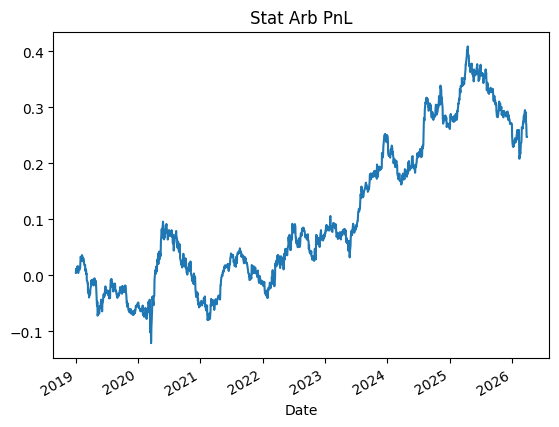

In [43]:
(pnl_series.cumsum()).plot(title="Stat Arb PnL")

<Axes: title={'center': 'Stat Arb (Hedged + Costs)'}, xlabel='Date'>

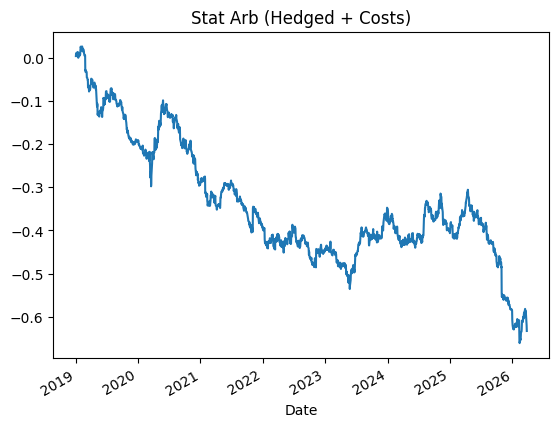

In [44]:

pnl_series = []
positions_prev = {}

dates = valid_dates[:-1]  # avoid last-day bug

for t in dates:

    # ---------------------------
    # 1. Build window + PCA
    # ---------------------------
    window_data = returns.loc[:t].tail(252).dropna(axis=1)

    mu = window_data.mean()
    sigma = window_data.std().replace(0, np.nan)
    window_data = window_data.dropna(axis=1)
    sigma = sigma.loc[window_data.columns]

    Y = (window_data - mu) / sigma

    corr = Y.corr()
    eigvals, eigvecs = np.linalg.eigh(corr)
    idx = np.argsort(eigvals)[::-1]
    V = eigvecs[:, idx][:, :15]

    # eigenportfolio weights
    Q = V / sigma.values[:, None]
    F = pd.DataFrame(window_data.values @ Q, index=window_data.index)

    # ---------------------------
    # 2. Regression window
    # ---------------------------
    reg_window = window_data.tail(60)
    F_reg = F.loc[reg_window.index]

    signals = {}
    betas = {}

    for stock in reg_window.columns:

        y = reg_window[stock]
        X = sm.add_constant(F_reg)

        model = sm.OLS(y, X).fit()
        resid = model.resid
        X_series = resid.cumsum()

        # AR(1)
        X_lag = X_series.shift(1).dropna()
        X_now = X_series.loc[X_lag.index]
        X_reg = sm.add_constant(X_lag)

        ar = sm.OLS(X_now, X_reg).fit()
        a = ar.params.iloc[0]
        b = ar.params.iloc[1]

        if not (0 < b < 1):
            continue

        kappa = -np.log(b) * 252
        if kappa <= 8.4:
            continue

        zeta = ar.resid
        m = a / (1 - b)
        sigma_eq = np.sqrt(zeta.var() / (1 - b**2))

        X_t = X_series.iloc[-1]
        s = (X_t - m) / sigma_eq

        if s < -1.25:
            signals[stock] = 1
        elif s > 1.25:
            signals[stock] = -1

        # store factor exposures (exclude intercept)
        betas[stock] = model.params.iloc[1:].values

    if len(signals) == 0:
        pnl_series.append(0)
        continue

    # ---------------------------
    # 3. Position sizing (equal weight first)
    # ---------------------------
    weights = pd.Series(signals)

    # normalize
    weights = weights / weights.abs().sum()

    # ---------------------------
    # 4. Factor-neutral hedge
    # ---------------------------
    B = np.array([betas[s] for s in weights.index])   # exposures
    w = weights.values

    # solve for hedge adjustment
    try:
        hedge = np.linalg.lstsq(B.T, w, rcond=None)[0]
        w_adj = w - B @ hedge
    except:
        w_adj = w

    weights = pd.Series(w_adj, index=weights.index)

    # normalize again
    weights = weights / weights.abs().sum()

    # ---------------------------
    # 5. Transaction costs
    # ---------------------------
    turnover = 0
    for stock in weights.index:
        prev = positions_prev.get(stock, 0)
        turnover += abs(weights[stock] - prev)

    cost = 0.001 * turnover  # 10 bps round-trip

    # ---------------------------
    # 6. PnL
    # ---------------------------
    idx = returns.index.get_loc(t)
    next_day = returns.index[idx + 1]

    pnl = 0
    for stock in weights.index:
        pnl += weights[stock] * returns.loc[next_day, stock]

    pnl -= cost

    pnl_series.append(pnl)

    # update positions
    positions_prev = weights.to_dict()

pnl_series = pd.Series(pnl_series, index=dates)

# ---------------------------
# Plot
# ---------------------------
(pnl_series.cumsum()).plot(title="Stat Arb (Hedged + Costs)")

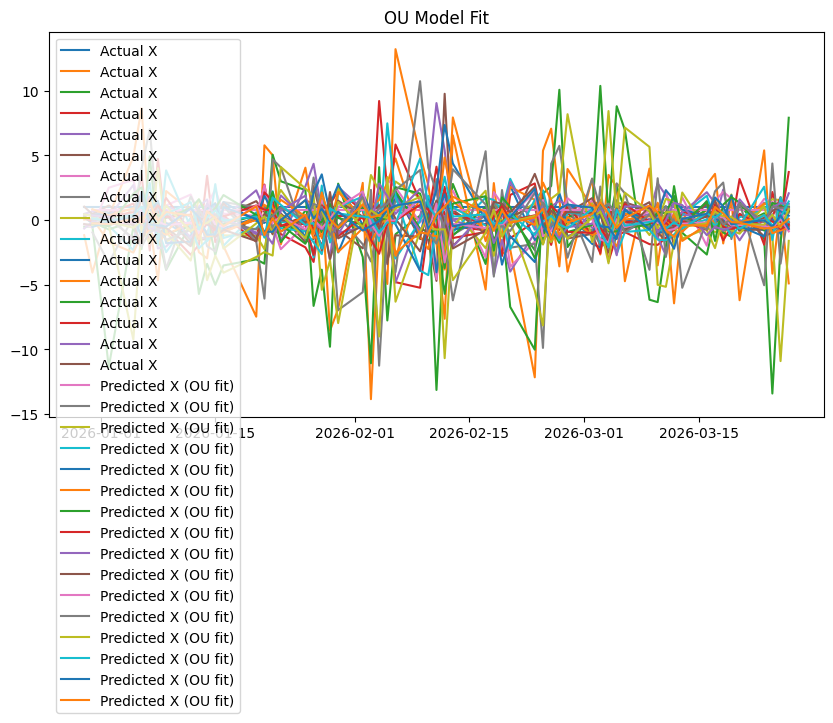

In [45]:
import matplotlib.pyplot as plt

# predicted next step from AR(1)
X_pred = a + b * X.shift(1)

plt.figure(figsize=(10,5))
plt.plot(X, label="Actual X")
plt.plot(X_pred, label="Predicted X (OU fit)")
plt.legend()
plt.title("OU Model Fit")
plt.show()

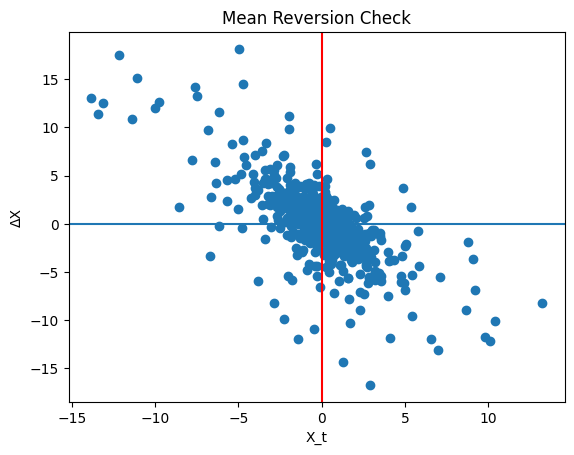

In [46]:
dX = X.diff()

plt.scatter(X.shift(1), dX)
plt.axhline(0)
plt.axvline(m, color='red')

plt.title("Mean Reversion Check")
plt.xlabel("X_t")
plt.ylabel("ΔX")
plt.show()

Mean: -6.269996292407697e-18
Std: 0.010060914084562056


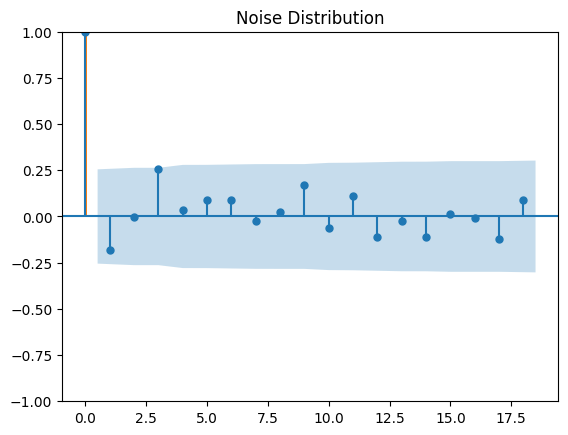

In [47]:
zeta = model_ar.resid

# autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(zeta)
plt.title("Noise Autocorrelation")

# distribution
plt.hist(zeta, bins=30)
plt.title("Noise Distribution")

print("Mean:", zeta.mean())
print("Std:", zeta.std())

In [48]:
half_life = np.log(2) / kappa
print("Half-life (days):", half_life * 252)

Half-life (days): 3.343572516772045


# optimize
## Hyperparameter Tuning Guide — Statistical Arbitrage

---

## Core Parameters (HIGH impact)

### Entry Threshold (s-score)
Try:
- 1.0
- 1.25
- 1.5
- 2.0  

**Tradeoff:**
- Lower → more trades, weaker signals  
- Higher → fewer trades, stronger signals  

---

### Exit Threshold
Paper uses asymmetric thresholds.

Try:
- 0.25
- 0.5
- 0.75  

---

### Holding Period
Match mean-reversion half-life (~3–5 days)

Try:
- 2 days  
- 3 days  
- 5 days  

---

## Model Structure (MEDIUM impact)

### Number of PCA Factors
Try:
- 10  
- 15  
- 20  

**Tradeoff:**
- Too many → removes alpha  
- Too few → insufficient neutrality  

---

### Regression Window
Try:
- 40 days  
- 60 days  
- 80 days  

---

### PCA Lookback Window
Try:
- 126 days (6 months)  
- 252 days (1 year)  
- 504 days (2 years)  

---

## Filters (VERY important)

### Kappa Filter (Mean Reversion Speed)
Try:
- $\kappa > 5$  
- $\kappa > 8.4$  
- $\kappa > 15$  

**Tradeoff:**
- Higher → stronger signals, fewer trades  

---

### Volatility Filter
Remove stocks with very low equilibrium volatility:

$$
\sigma_{\text{eq}, i} = \frac{\sigma_i}{\sqrt{2\kappa_i}}
$$

Low $\sigma_{\text{eq}}$ → weak signals → not tradable  

---

## Portfolio Construction (CRITICAL)

### Position Sizing

Do **NOT** use equal weights ❌  

Instead scale positions:

$$
w_i \propto \frac{1}{\sigma_{\text{eq}, i}}
$$

**Intuition:**
- Lower risk → larger allocation  
- Higher risk → smaller allocation  

---

### Dollar Neutrality

Maintain:

$$
\sum_i w_i = 0
$$

- Long = Short exposure  
- Avoid market direction bias  

**Important:**  
Do NOT over-hedge early — keep model simple  

---

## Execution (ALPHA killer)

### Transaction Costs
Test:
- 5 bps  
- 10 bps  

Even small costs can destroy alpha  

---

### Rebalance Frequency

Avoid:
- Daily rebalancing ❌  

Try:
- Every 2–3 days  

Reduces turnover and costs  

---

## What NOT to Over-Optimize

These are already structurally correct:

- OU process ❌  
- PCA method ❌  
- Regression type ❌  

Focus optimization on:
- thresholds  
- filters  
- execution  

---

## Core Insight

Alpha comes from:

- Strong signals (high $|s_i|$)  
- Fast mean reversion (high $\kappa$)  
- Low costs  

Not from over-engineering the model.